In [43]:
pip install fredapi pandas numpy matplotlib seaborn

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred

fred = Fred(api_key='2bee96f44d3728f0d85ac32990597e33')

print("Connected to FRED API successfully!")

Connected to FRED API successfully!


In [45]:
unemployment = fred.get_series('UNRATE', observation_start='2010-01-01')
delinquency_rate = fred.get_series('DRCCLACBS', observation_start='2010-01-01')
consumer_debt = fred.get_series('TOTALSL', observation_start='2010-01-01')
interest_rate = fred.get_series('FEDFUNDS', observation_start='2010-01-01')

df_unemployment = pd.DataFrame({'date': unemployment.index, 'unemployment_rate': unemployment.values})
df_delinquency = pd.DataFrame({'date': delinquency_rate.index, 'delinquency_rate': delinquency_rate.values})
df_consumer_debt = pd.DataFrame({'date': consumer_debt.index, 'consumer_debt_billions': consumer_debt.values})
df_interest_rate = pd.DataFrame({'date': interest_rate.index, 'interest_rate': interest_rate.values})

print("Unemployment Rate — rows:", len(df_unemployment))
print("Delinquency Rate — rows:", len(df_delinquency))
print("Consumer Debt — rows:", len(df_consumer_debt))
print("Interest Rate — rows:", len(df_interest_rate))

Unemployment Rate — rows: 197
Delinquency Rate — rows: 65
Consumer Debt — rows: 196
Interest Rate — rows: 197


In [46]:
df_fred = df_unemployment.merge(df_delinquency, on='date', how='outer')
df_fred = df_fred.merge(df_consumer_debt, on='date', how='outer')
df_fred = df_fred.merge(df_interest_rate, on='date', how='outer')

df_fred = df_fred.sort_values('date').reset_index(drop=True)

print("Combined FRED Dataset Shape:", df_fred.shape)
print("\nFirst 5 rows:")
print(df_fred.head())
print("\nMissing values:")
print(df_fred.isnull().sum())

Combined FRED Dataset Shape: (197, 5)

First 5 rows:
        date  unemployment_rate  delinquency_rate  consumer_debt_billions  \
0 2010-01-01                9.8              5.78              2543508.02   
1 2010-02-01                9.8               NaN              2530024.28   
2 2010-03-01                9.9               NaN              2536551.95   
3 2010-04-01                9.9              5.10              2532764.79   
4 2010-05-01                9.6               NaN              2521687.94   

   interest_rate  
0           0.11  
1           0.13  
2           0.16  
3           0.20  
4           0.20  

Missing values:
date                        0
unemployment_rate           1
delinquency_rate          132
consumer_debt_billions      1
interest_rate               0
dtype: int64


In [47]:
df_fred['delinquency_rate'] = df_fred['delinquency_rate'].fillna(method='ffill')

df_fred = df_fred.dropna()

df_fred = df_fred.reset_index(drop=True)

print("Shape after cleaning:", df_fred.shape)
print("\nMissing values after cleaning:")
print(df_fred.isnull().sum())
print("\nFirst 5 rows after cleaning:")
print(df_fred.head())

Shape after cleaning: (195, 5)

Missing values after cleaning:
date                      0
unemployment_rate         0
delinquency_rate          0
consumer_debt_billions    0
interest_rate             0
dtype: int64

First 5 rows after cleaning:
        date  unemployment_rate  delinquency_rate  consumer_debt_billions  \
0 2010-01-01                9.8              5.78              2543508.02   
1 2010-02-01                9.8              5.78              2530024.28   
2 2010-03-01                9.9              5.78              2536551.95   
3 2010-04-01                9.9              5.10              2532764.79   
4 2010-05-01                9.6              5.10              2521687.94   

   interest_rate  
0           0.11  
1           0.13  
2           0.16  
3           0.20  
4           0.20  


/tmp/ipykernel_38969/184254101.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_fred['delinquency_rate'] = df_fred['delinquency_rate'].fillna(method='ffill')


In [48]:
df_loans = pd.read_csv('accepted_2007_to_2018Q4.csv', low_memory=False)

print("Shape:", df_loans.shape)
print("\nFirst 5 rows:")
print(df_loans.head())
print("\nColumn names:")
print(df_loans.columns.tolist())

Shape: (2260701, 151)

First 5 rows:
         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277        NaN     3600.0       3600.0           3600.0   36 months   
1  68355089        NaN    24700.0      24700.0          24700.0   36 months   
2  68341763        NaN    20000.0      20000.0          20000.0   60 months   
3  66310712        NaN    35000.0      35000.0          35000.0   60 months   
4  68476807        NaN    10400.0      10400.0          10400.0   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.99       123.03     C        C4  ...                            NaN   
1     11.99       820.28     C        C1  ...                            NaN   
2     10.78       432.66     B        B4  ...                            NaN   
3     14.85       829.90     C        C5  ...                            NaN   
4     22.45       289.91     F        F1  ...                            NaN   

  hards

In [49]:
cols = [
    'loan_amnt', 'term', 'int_rate', 'grade', 'emp_length',
    'annual_inc', 'loan_status', 'purpose', 'dti',
    'fico_range_low', 'delinq_2yrs', 'revol_util',
    'home_ownership', 'addr_state', 'total_acc', 'pub_rec'
]

df_loans = df_loans[cols]

print("Shape after selecting columns:", df_loans.shape)
print("\nMissing values:")
print(df_loans.isnull().sum())
print("\nLoan Status values:")
print(df_loans['loan_status'].value_counts())

Shape after selecting columns: (2260701, 16)

Missing values:
loan_amnt             33
term                  33
int_rate              33
grade                 33
emp_length        146940
annual_inc            37
loan_status           33
purpose               33
dti                 1744
fico_range_low        33
delinq_2yrs           62
revol_util          1835
home_ownership        33
addr_state            33
total_acc             62
pub_rec               62
dtype: int64

Loan Status values:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off

In [50]:
df_loans = df_loans[df_loans['loan_status'].isin(['Fully Paid', 'Charged Off'])]

df_loans['default'] = (df_loans['loan_status'] == 'Charged Off').astype(int)

df_loans = df_loans.drop('loan_status', axis=1)

df_loans['emp_length'] = df_loans['emp_length'].fillna('Unknown')

df_loans = df_loans.dropna()

df_loans = df_loans.reset_index(drop=True)

print("Shape after cleaning:", df_loans.shape)
print("\nDefault distribution:")
print(df_loans['default'].value_counts())
print("\nDefault rate:", round(df_loans['default'].mean() * 100, 2), "%")

Shape after cleaning: (1344080, 16)

Default distribution:
default
0    1075772
1     268308
Name: count, dtype: int64

Default rate: 19.96 %


In [51]:
df_loans.to_csv('loans_cleaned.csv', index=False)
df_fred.to_csv('fred_cleaned.csv', index=False)

print("loans_cleaned.csv saved!")
print("fred_cleaned.csv saved!")
print("\nLoans file size:", round(df_loans.memory_usage(deep=True).sum() / 1024**2, 2), "MB")
print("FRED file size:", round(df_fred.memory_usage(deep=True).sum() / 1024**2, 2), "MB")

loans_cleaned.csv saved!
fred_cleaned.csv saved!

Loans file size: 532.54 MB
FRED file size: 0.01 MB


In [52]:
df_loans_sample = df_loans.groupby('default', group_keys=False).apply(
    lambda x: x.sample(frac=0.037, random_state=42)
).reset_index(drop=True)

print("Sample shape:", df_loans_sample.shape)
print("\nDefault distribution in sample:")
print(df_loans_sample['default'].value_counts())
print("\nDefault rate in sample:", round(df_loans_sample['default'].mean() * 100, 2), "%")

df_loans_sample.to_csv('loans_sample.csv', index=False)
print("\nloans_sample.csv saved!")

/tmp/ipykernel_38969/3318925476.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_loans_sample = df_loans.groupby('default', group_keys=False).apply(


Sample shape: (49731, 16)

Default distribution in sample:
default
0    39804
1     9927
Name: count, dtype: int64

Default rate in sample: 19.96 %

loans_sample.csv saved!


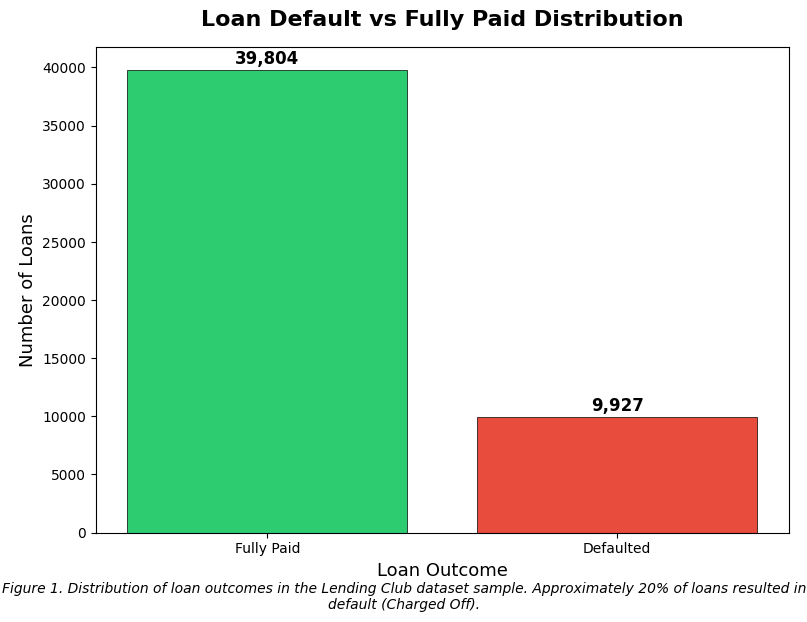

In [53]:
# Visualization 1 — Default vs Fully Paid Distribution
plt.figure(figsize=(8, 6))

counts = df_loans_sample['default'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = plt.bar(['Fully Paid', 'Defaulted'], counts.values, color=colors, edgecolor='black', linewidth=0.5)

for bar, count in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{count:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Loan Default vs Fully Paid Distribution', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Loan Outcome', fontsize=13)
plt.ylabel('Number of Loans', fontsize=13)
plt.figtext(0.5, -0.02,
            'Figure 1. Distribution of loan outcomes in the Lending Club dataset sample. '
            'Approximately 20% of loans resulted in default (Charged Off).',
            ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('viz1_default_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

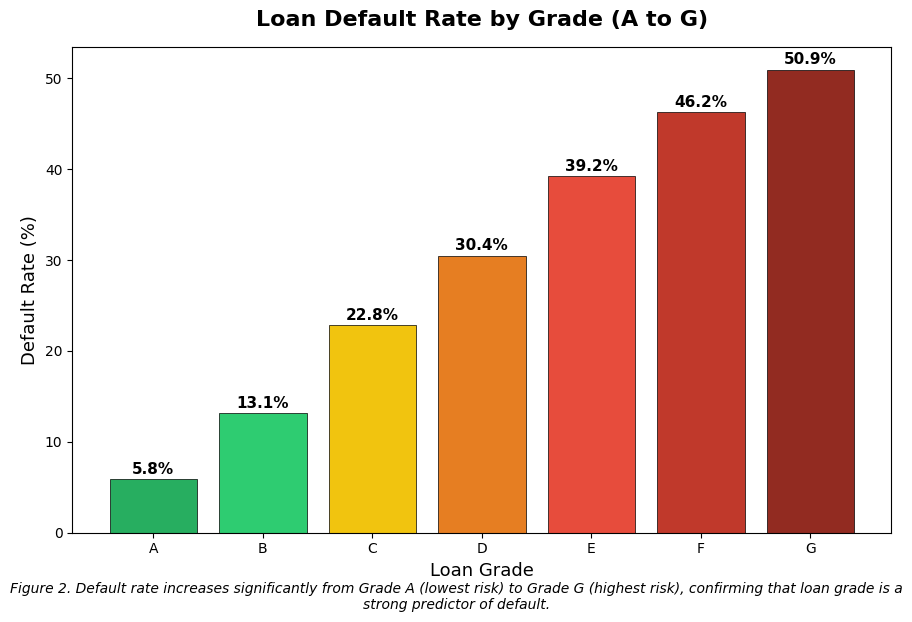

In [54]:
# Visualization 2 — Default Rate by Loan Grade
plt.figure(figsize=(9, 6))

grade_default = df_loans_sample.groupby('grade')['default'].mean() * 100
grade_default = grade_default.sort_index()

colors = ['#27ae60', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b', '#922b21']
bars = plt.bar(grade_default.index, grade_default.values, color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, grade_default.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Loan Default Rate by Grade (A to G)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Loan Grade', fontsize=13)
plt.ylabel('Default Rate (%)', fontsize=13)
plt.figtext(0.5, -0.02,
            'Figure 2. Default rate increases significantly from Grade A (lowest risk) '
            'to Grade G (highest risk), confirming that loan grade is a strong predictor of default.',
            ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('viz2_default_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()

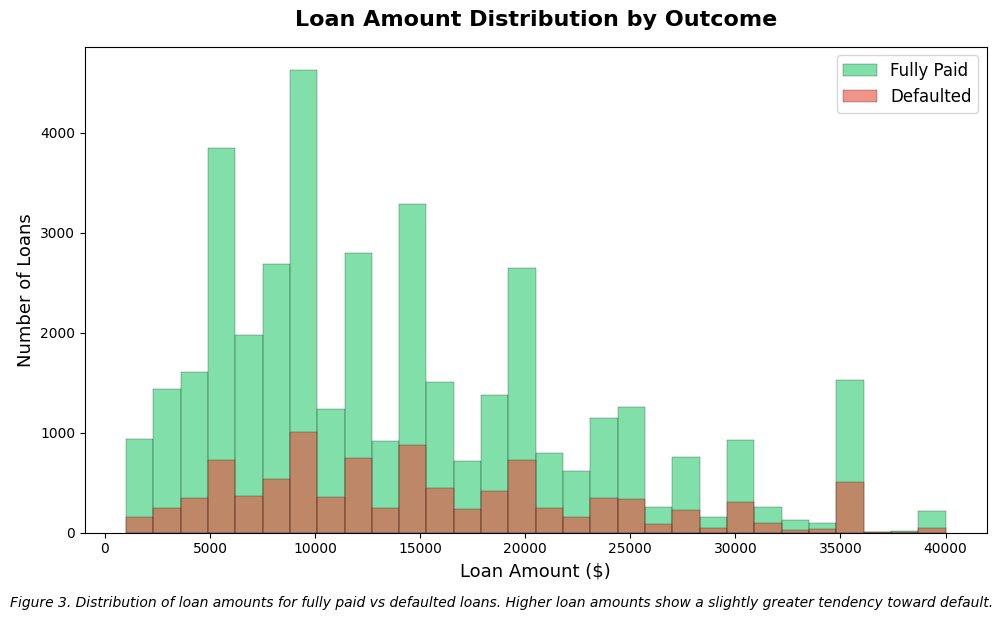

In [55]:
# Visualization 3 — Loan Amount Distribution
plt.figure(figsize=(10, 6))

plt.hist(df_loans_sample[df_loans_sample['default']==0]['loan_amnt'],
         bins=30, alpha=0.6, color='#2ecc71', label='Fully Paid', edgecolor='black', linewidth=0.3)
plt.hist(df_loans_sample[df_loans_sample['default']==1]['loan_amnt'],
         bins=30, alpha=0.6, color='#e74c3c', label='Defaulted', edgecolor='black', linewidth=0.3)

plt.title('Loan Amount Distribution by Outcome', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Loan Amount ($)', fontsize=13)
plt.ylabel('Number of Loans', fontsize=13)
plt.legend(fontsize=12)
plt.figtext(0.5, -0.02,
            'Figure 3. Distribution of loan amounts for fully paid vs defaulted loans. '
            'Higher loan amounts show a slightly greater tendency toward default.',
            ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('viz3_loan_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_38969/1585754932.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=['Fully Paid', 'Defaulted'],


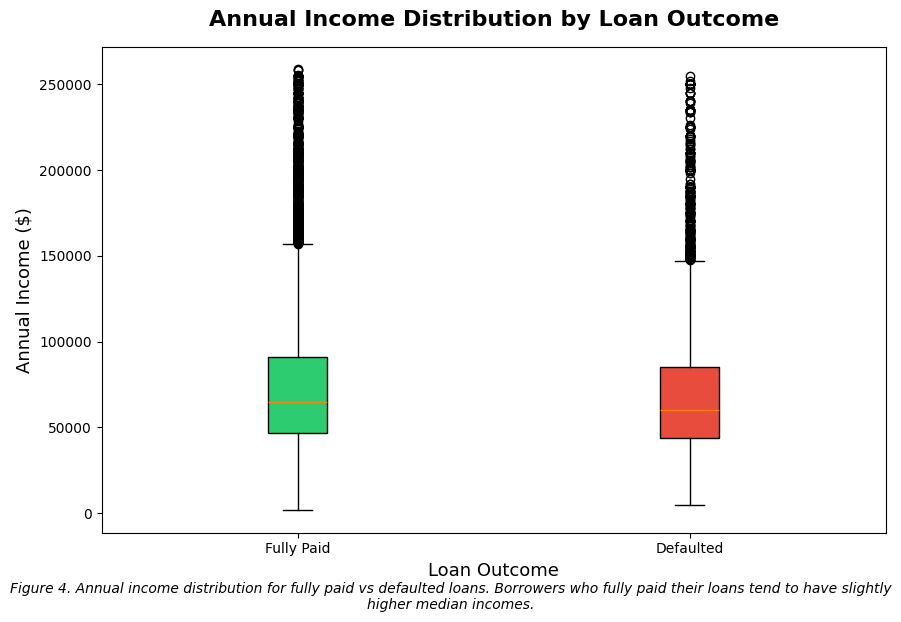

In [56]:
# Visualization 4 — Annual Income vs Default (Box Plot)
plt.figure(figsize=(9, 6))

income_cap = df_loans_sample['annual_inc'].quantile(0.99)
df_plot = df_loans_sample[df_loans_sample['annual_inc'] < income_cap]

data_to_plot = [
    df_plot[df_plot['default']==0]['annual_inc'],
    df_plot[df_plot['default']==1]['annual_inc']
]

bp = plt.boxplot(data_to_plot, labels=['Fully Paid', 'Defaulted'],
                 patch_artist=True, notch=False)

bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')

plt.title('Annual Income Distribution by Loan Outcome', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Loan Outcome', fontsize=13)
plt.ylabel('Annual Income ($)', fontsize=13)
plt.figtext(0.5, -0.02,
            'Figure 4. Annual income distribution for fully paid vs defaulted loans. '
            'Borrowers who fully paid their loans tend to have slightly higher median incomes.',
            ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('viz4_income_vs_default.png', dpi=150, bbox_inches='tight')
plt.show()

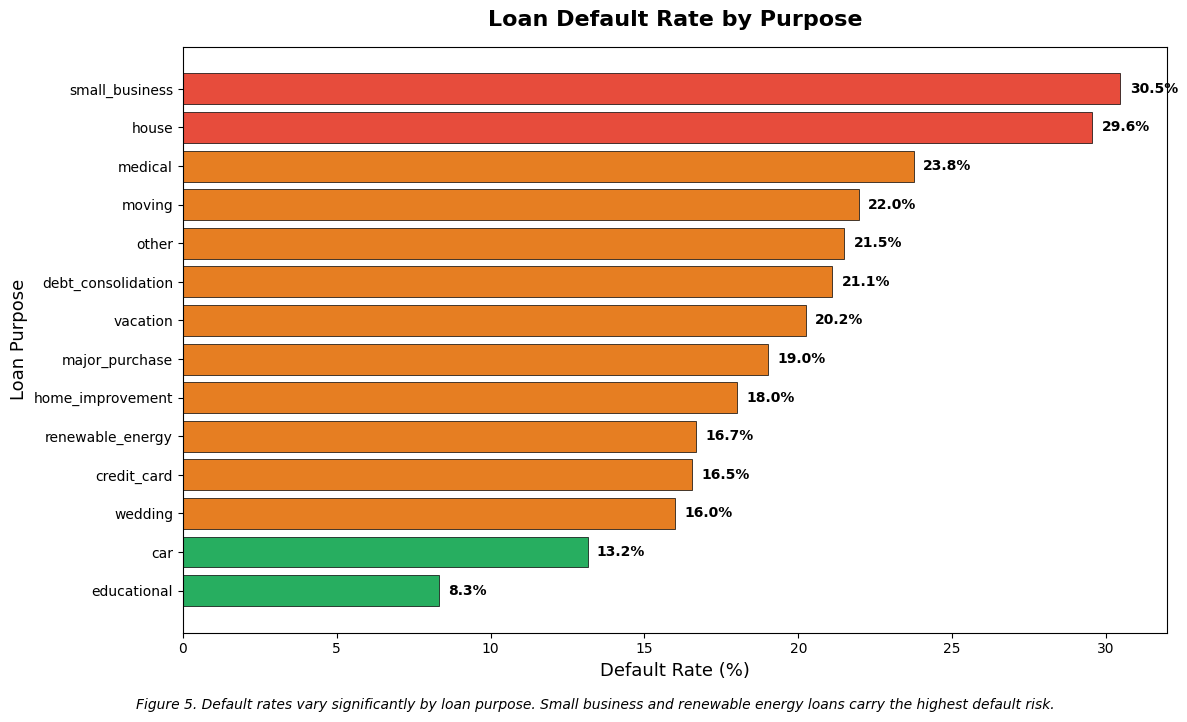

In [57]:
# Visualization 5 — Default Rate by Loan Purpose
plt.figure(figsize=(12, 7))

purpose_default = df_loans_sample.groupby('purpose')['default'].mean() * 100
purpose_default = purpose_default.sort_values(ascending=True)

colors = ['#27ae60' if x < 15 else '#e67e22' if x < 25 else '#e74c3c' for x in purpose_default.values]
bars = plt.barh(purpose_default.index, purpose_default.values, color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, purpose_default.values):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', ha='left', va='center', fontsize=10, fontweight='bold')

plt.title('Loan Default Rate by Purpose', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Default Rate (%)', fontsize=13)
plt.ylabel('Loan Purpose', fontsize=13)
plt.figtext(0.5, -0.02,
            'Figure 5. Default rates vary significantly by loan purpose. '
            'Small business and renewable energy loans carry the highest default risk.',
            ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('viz5_default_by_purpose.png', dpi=150, bbox_inches='tight')
plt.show()

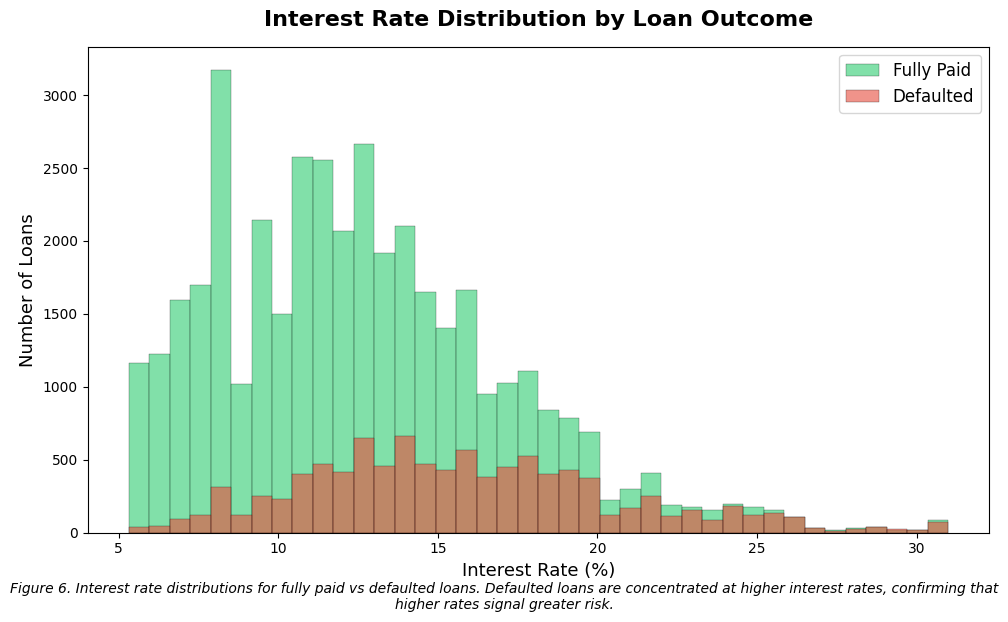

In [58]:
# Visualization 6 — Interest Rate Distribution by Outcome
plt.figure(figsize=(10, 6))

plt.hist(df_loans_sample[df_loans_sample['default']==0]['int_rate'],
         bins=40, alpha=0.6, color='#2ecc71', label='Fully Paid', edgecolor='black', linewidth=0.3)
plt.hist(df_loans_sample[df_loans_sample['default']==1]['int_rate'],
         bins=40, alpha=0.6, color='#e74c3c', label='Defaulted', edgecolor='black', linewidth=0.3)

plt.title('Interest Rate Distribution by Loan Outcome', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Interest Rate (%)', fontsize=13)
plt.ylabel('Number of Loans', fontsize=13)
plt.legend(fontsize=12)
plt.figtext(0.5, -0.02,
            'Figure 6. Interest rate distributions for fully paid vs defaulted loans. '
            'Defaulted loans are concentrated at higher interest rates, confirming '
            'that higher rates signal greater risk.',
            ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('viz6_interest_rate_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

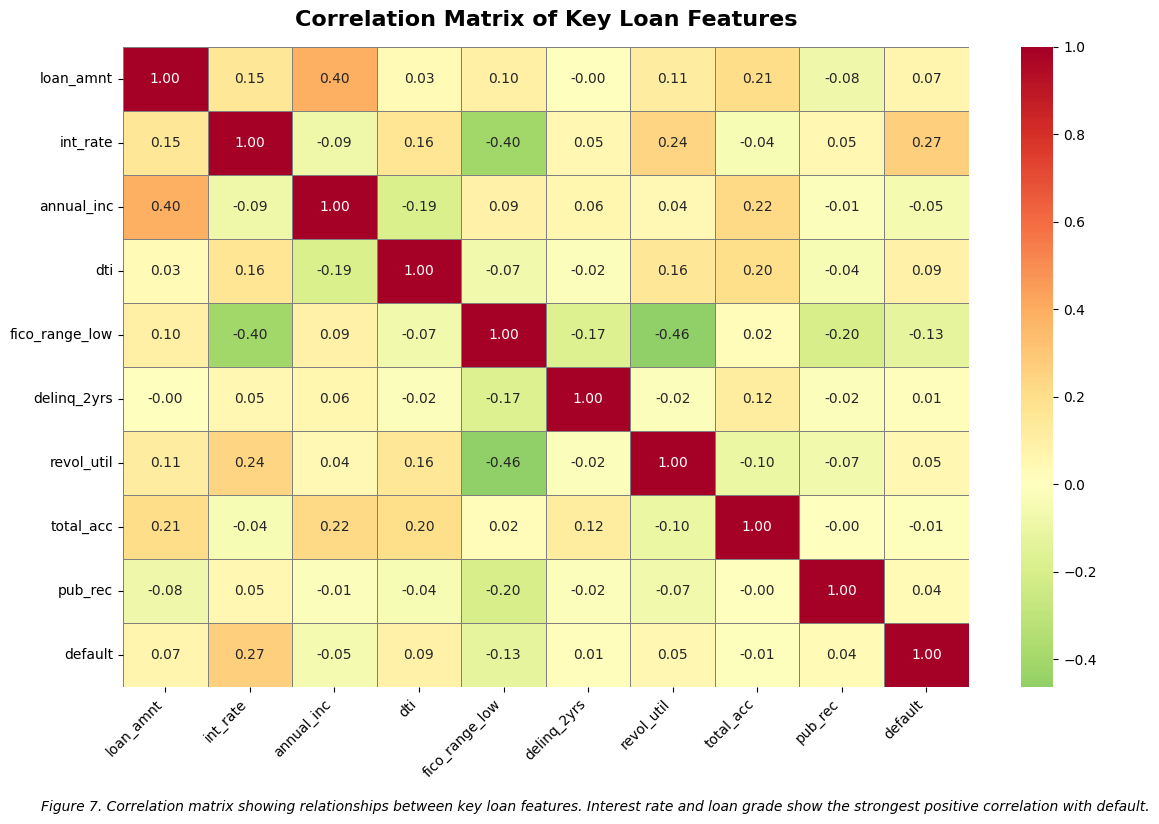

In [59]:
# Visualization 7 — Correlation Heatmap
plt.figure(figsize=(12, 8))

numeric_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti',
                'fico_range_low', 'delinq_2yrs', 'revol_util',
                'total_acc', 'pub_rec', 'default']

corr_matrix = df_loans_sample[numeric_cols].corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn_r',
            center=0,
            linewidths=0.5,
            linecolor='gray',
            annot_kws={'size': 10})

plt.title('Correlation Matrix of Key Loan Features', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.figtext(0.5, -0.02,
            'Figure 7. Correlation matrix showing relationships between key loan features. '
            'Interest rate and loan grade show the strongest positive correlation with default.',
            ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('viz7_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

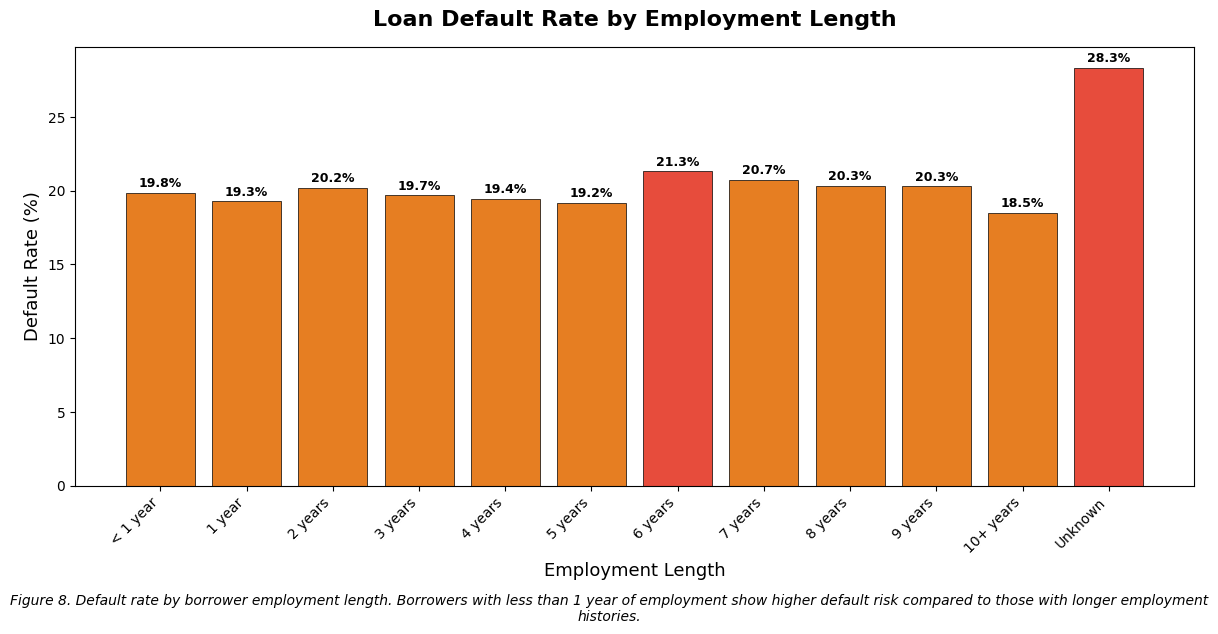

In [60]:
# Visualization 8 — Default Rate by Employment Length
plt.figure(figsize=(12, 6))

emp_order = ['< 1 year', '1 year', '2 years', '3 years', '4 years',
             '5 years', '6 years', '7 years', '8 years', '9 years', '10+ years', 'Unknown']

emp_default = df_loans_sample.groupby('emp_length')['default'].mean() * 100
emp_default = emp_default.reindex(emp_order)

colors = ['#e74c3c' if x > 21 else '#e67e22' if x > 18 else '#2ecc71' for x in emp_default.values]
bars = plt.bar(emp_default.index, emp_default.values, color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, emp_default.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Loan Default Rate by Employment Length', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Employment Length', fontsize=13)
plt.ylabel('Default Rate (%)', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.figtext(0.5, -0.04,
            'Figure 8. Default rate by borrower employment length. '
            'Borrowers with less than 1 year of employment show higher default risk '
            'compared to those with longer employment histories.',
            ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('viz8_default_by_employment.png', dpi=150, bbox_inches='tight')
plt.show()

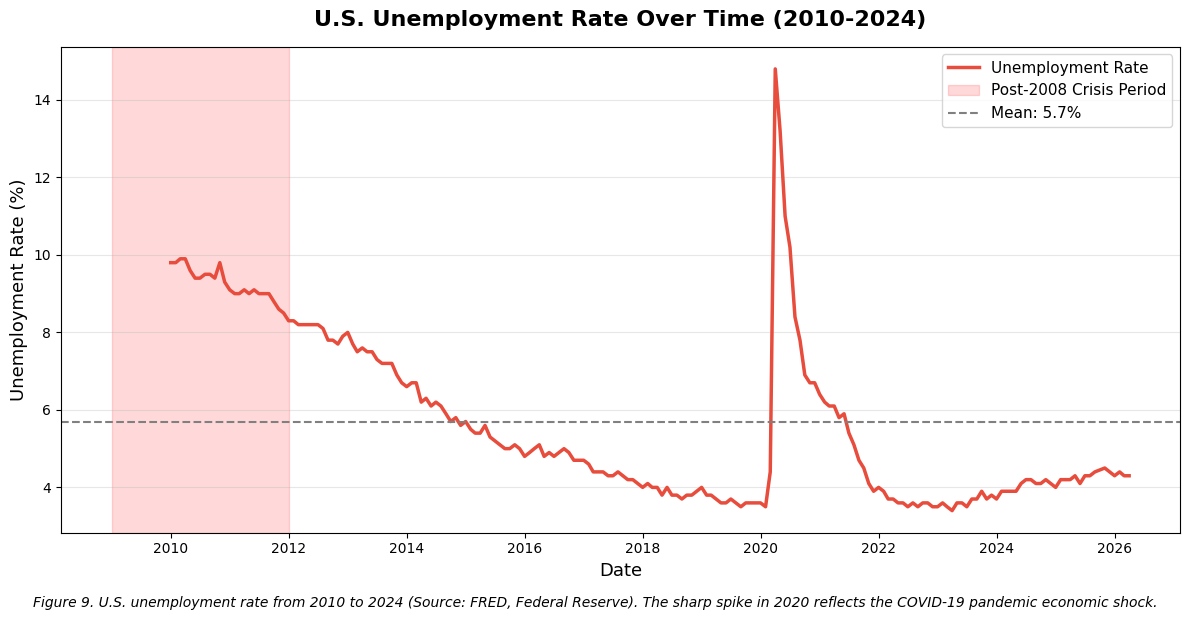

In [61]:
# Visualization 9 — Unemployment Rate Over Time (FRED Data)
plt.figure(figsize=(12, 6))

plt.plot(df_fred['date'], df_fred['unemployment_rate'],
         color='#e74c3c', linewidth=2.5, label='Unemployment Rate')

plt.axvspan(pd.Timestamp('2009-01-01'), pd.Timestamp('2012-01-01'),
            alpha=0.15, color='red', label='Post-2008 Crisis Period')

plt.axhline(y=df_fred['unemployment_rate'].mean(),
            color='gray', linestyle='--', linewidth=1.5, label=f'Mean: {df_fred["unemployment_rate"].mean():.1f}%')

plt.title('U.S. Unemployment Rate Over Time (2010-2024)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=13)
plt.ylabel('Unemployment Rate (%)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.figtext(0.5, -0.02,
            'Figure 9. U.S. unemployment rate from 2010 to 2024 (Source: FRED, Federal Reserve). '
            'The sharp spike in 2020 reflects the COVID-19 pandemic economic shock.',
            ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('viz9_unemployment_rate.png', dpi=150, bbox_inches='tight')
plt.show()

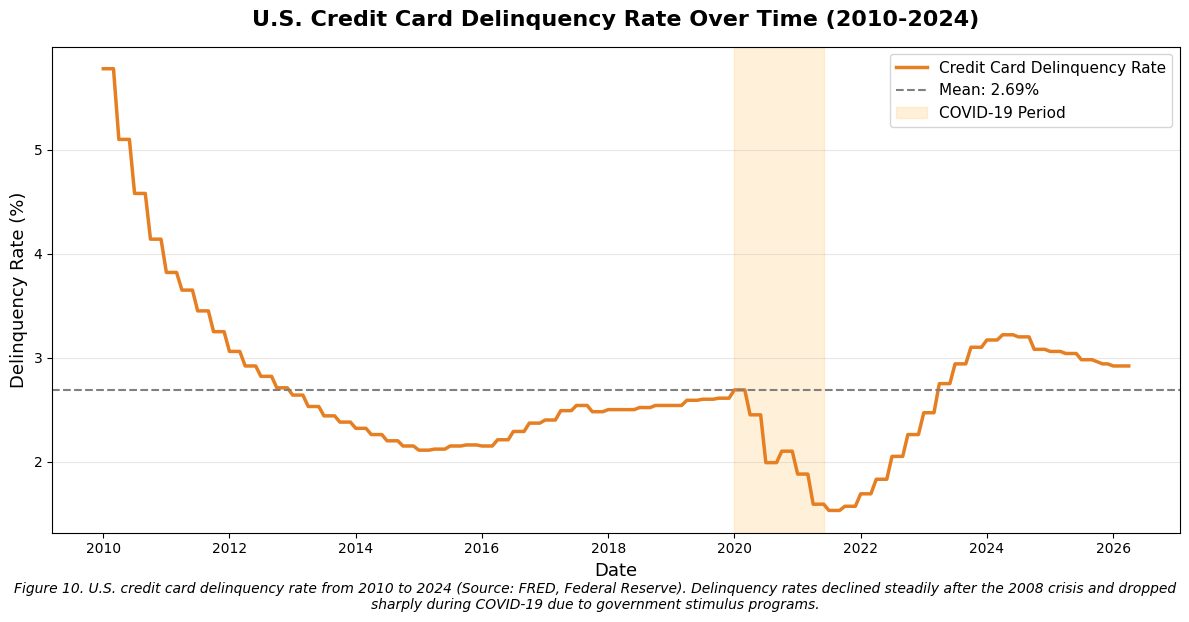

In [62]:
# Visualization 10 — Delinquency Rate Over Time (FRED Data)
plt.figure(figsize=(12, 6))

plt.plot(df_fred['date'], df_fred['delinquency_rate'],
         color='#e67e22', linewidth=2.5, label='Credit Card Delinquency Rate')

plt.axhline(y=df_fred['delinquency_rate'].mean(),
            color='gray', linestyle='--', linewidth=1.5,
            label=f'Mean: {df_fred["delinquency_rate"].mean():.2f}%')

plt.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-06-01'),
            alpha=0.15, color='orange', label='COVID-19 Period')

plt.title('U.S. Credit Card Delinquency Rate Over Time (2010-2024)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=13)
plt.ylabel('Delinquency Rate (%)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.figtext(0.5, -0.02,
            'Figure 10. U.S. credit card delinquency rate from 2010 to 2024 (Source: FRED, Federal Reserve). '
            'Delinquency rates declined steadily after the 2008 crisis and dropped sharply during '
            'COVID-19 due to government stimulus programs.',
            ha='center', fontsize=10, style='italic', wrap=True)

plt.tight_layout()
plt.savefig('viz10_delinquency_rate.png', dpi=150, bbox_inches='tight')
plt.show()

In [63]:
import pandas as pd
df_raw = pd.read_csv('accepted_2007_to_2018Q4.csv', nrows=5, low_memory=False)
print("RAW DATA - First 5 rows:")
print(df_raw[['id','loan_amnt','term','int_rate','grade','emp_length','annual_inc','loan_status','purpose','dti']].head())

RAW DATA - First 5 rows:
         id  loan_amnt        term  int_rate grade emp_length  annual_inc  \
0  68407277     3600.0   36 months     13.99     C  10+ years     55000.0   
1  68355089    24700.0   36 months     11.99     C  10+ years     65000.0   
2  68341763    20000.0   60 months     10.78     B  10+ years     63000.0   
3  66310712    35000.0   60 months     14.85     C  10+ years    110000.0   
4  68476807    10400.0   60 months     22.45     F    3 years    104433.0   

  loan_status             purpose    dti  
0  Fully Paid  debt_consolidation   5.91  
1  Fully Paid      small_business  16.06  
2  Fully Paid    home_improvement  10.78  
3     Current  debt_consolidation  17.06  
4  Fully Paid      major_purchase  25.37  


In [64]:
print("CLEANED DATA - First 5 rows:")
print(df_loans.head())

CLEANED DATA - First 5 rows:
   loan_amnt        term  int_rate grade emp_length  annual_inc  \
0     3600.0   36 months     13.99     C  10+ years     55000.0   
1    24700.0   36 months     11.99     C  10+ years     65000.0   
2    20000.0   60 months     10.78     B  10+ years     63000.0   
3    10400.0   60 months     22.45     F    3 years    104433.0   
4    11950.0   36 months     13.44     C    4 years     34000.0   

              purpose    dti  fico_range_low  delinq_2yrs  revol_util  \
0  debt_consolidation   5.91           675.0          0.0        29.7   
1      small_business  16.06           715.0          1.0        19.2   
2    home_improvement  10.78           695.0          0.0        56.2   
3      major_purchase  25.37           695.0          1.0        64.5   
4  debt_consolidation  10.20           690.0          0.0        68.4   

  home_ownership addr_state  total_acc  pub_rec  default  
0       MORTGAGE         PA       13.0      0.0        0  
1       MOR

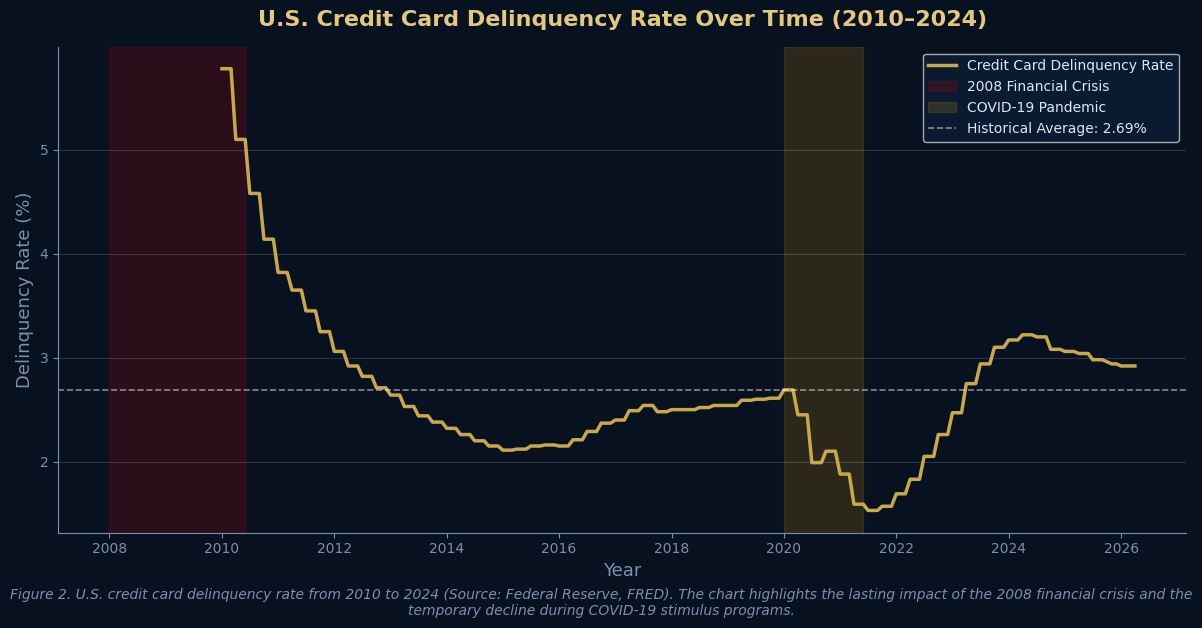

In [65]:
# Second Introduction Image — U.S. Loan Default Rate Over Time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_fred['date'], df_fred['delinquency_rate'],
        color='#c8a84b', linewidth=2.5, label='Credit Card Delinquency Rate')

ax.axvspan(pd.Timestamp('2008-01-01'), pd.Timestamp('2010-06-01'),
           alpha=0.15, color='red', label='2008 Financial Crisis')

ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-06-01'),
           alpha=0.15, color='orange', label='COVID-19 Pandemic')

ax.axhline(y=df_fred['delinquency_rate'].mean(),
           color='white', linestyle='--', linewidth=1.2, alpha=0.5,
           label=f'Historical Average: {df_fred["delinquency_rate"].mean():.2f}%')

ax.set_facecolor('#07111f')
fig.patch.set_facecolor('#07111f')
ax.tick_params(colors='#7a90b0')
ax.xaxis.label.set_color('#7a90b0')
ax.yaxis.label.set_color('#7a90b0')
ax.spines['bottom'].set_color('#7a90b0')
ax.spines['left'].set_color('#7a90b0')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(facecolor='#0c1e36', labelcolor='#dce6f5', fontsize=10)
ax.grid(axis='y', alpha=0.15, color='white')

ax.set_title('U.S. Credit Card Delinquency Rate Over Time (2010–2024)',
             fontsize=16, fontweight='bold', color='#e2c97e', pad=15)
ax.set_xlabel('Year', fontsize=13, color='#7a90b0')
ax.set_ylabel('Delinquency Rate (%)', fontsize=13, color='#7a90b0')

plt.figtext(0.5, -0.03,
            'Figure 2. U.S. credit card delinquency rate from 2010 to 2024 (Source: Federal Reserve, FRED). '
            'The chart highlights the lasting impact of the 2008 financial crisis and the temporary decline during COVID-19 stimulus programs.',
            ha='center', fontsize=10, style='italic', color='#7a90b0', wrap=True)

plt.tight_layout()
plt.savefig('intro_delinquency_chart.png', dpi=150, bbox_inches='tight',
            facecolor='#07111f')
plt.show()

In [66]:
# Install required library
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import numpy as np
import pandas as pd

cluster_features = ['loan_amnt', 'int_rate', 'annual_inc', 'dti',
                    'fico_range_low', 'revol_util', 'delinq_2yrs',
                    'total_acc', 'pub_rec']

df_cluster = df_loans[cluster_features].dropna().sample(5000, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print("Clustering data shape:", X_scaled.shape)
print("Features:", cluster_features)

Clustering data shape: (5000, 9)
Features: ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low', 'revol_util', 'delinq_2yrs', 'total_acc', 'pub_rec']


In [67]:
# Find best k using Silhouette scores
silhouette_scores = []
k_values = [2, 3, 4]

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k} — Silhouette Score: {score:.4f}")

best_k = k_values[silhouette_scores.index(max(silhouette_scores))]
print(f"\nBest k: {best_k}")

k=2 — Silhouette Score: 0.1582
k=3 — Silhouette Score: 0.1503
k=4 — Silhouette Score: 0.1607

Best k: 4


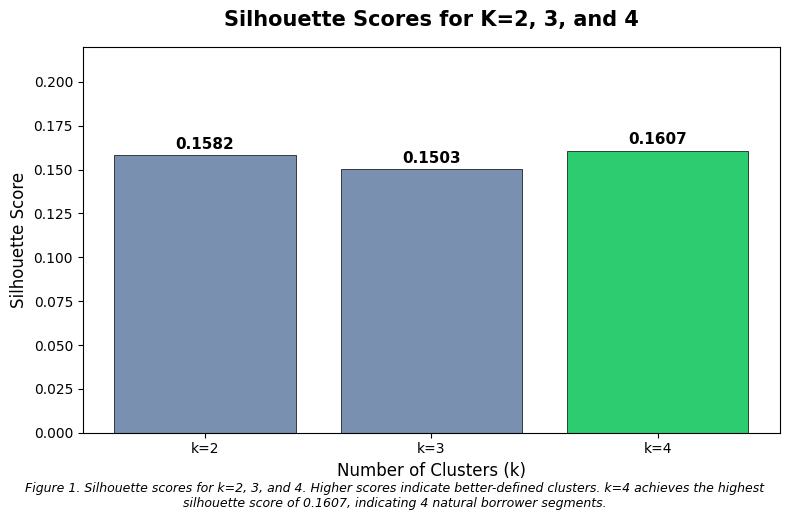

In [68]:
# Visualization 1 — Silhouette Scores for k=2, 3, 4
plt.figure(figsize=(8, 5))
colors = ['#2ecc71' if s == max(silhouette_scores) else '#7a90b0' for s in silhouette_scores]
bars = plt.bar([f'k={k}' for k in k_values], silhouette_scores, color=colors, edgecolor='black', linewidth=0.5)

for bar, score in zip(bars, silhouette_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{score:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Silhouette Scores for K=2, 3, and 4', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.ylim(0, 0.22)
plt.figtext(0.5, -0.02,
            'Figure 1. Silhouette scores for k=2, 3, and 4. Higher scores indicate better-defined clusters. '
            'k=4 achieves the highest silhouette score of 0.1607, indicating 4 natural borrower segments.',
            ha='center', fontsize=9, style='italic', wrap=True)
plt.tight_layout()
plt.savefig('clustering_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

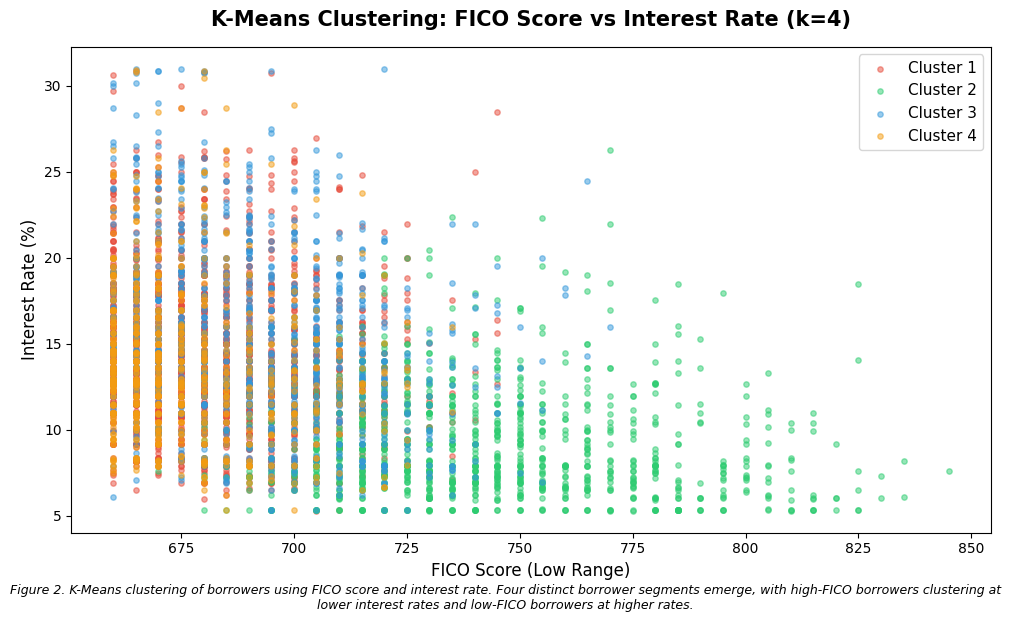

In [69]:
# Run K-Means with best k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
df_cluster['cluster'] = labels

# Visualization 2 — K-Means Clusters (Interest Rate vs FICO Score)
plt.figure(figsize=(10, 6))
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
cluster_names = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

for i in range(4):
    mask = labels == i
    plt.scatter(df_cluster[mask]['fico_range_low'],
                df_cluster[mask]['int_rate'],
                c=colors[i], label=cluster_names[i],
                alpha=0.5, s=15)

plt.title('K-Means Clustering: FICO Score vs Interest Rate (k=4)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('FICO Score (Low Range)', fontsize=12)
plt.ylabel('Interest Rate (%)', fontsize=12)
plt.legend(fontsize=11)
plt.figtext(0.5, -0.02,
            'Figure 2. K-Means clustering of borrowers using FICO score and interest rate. '
            'Four distinct borrower segments emerge, with high-FICO borrowers clustering at lower interest rates '
            'and low-FICO borrowers at higher rates.',
            ha='center', fontsize=9, style='italic', wrap=True)
plt.tight_layout()
plt.savefig('clustering_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

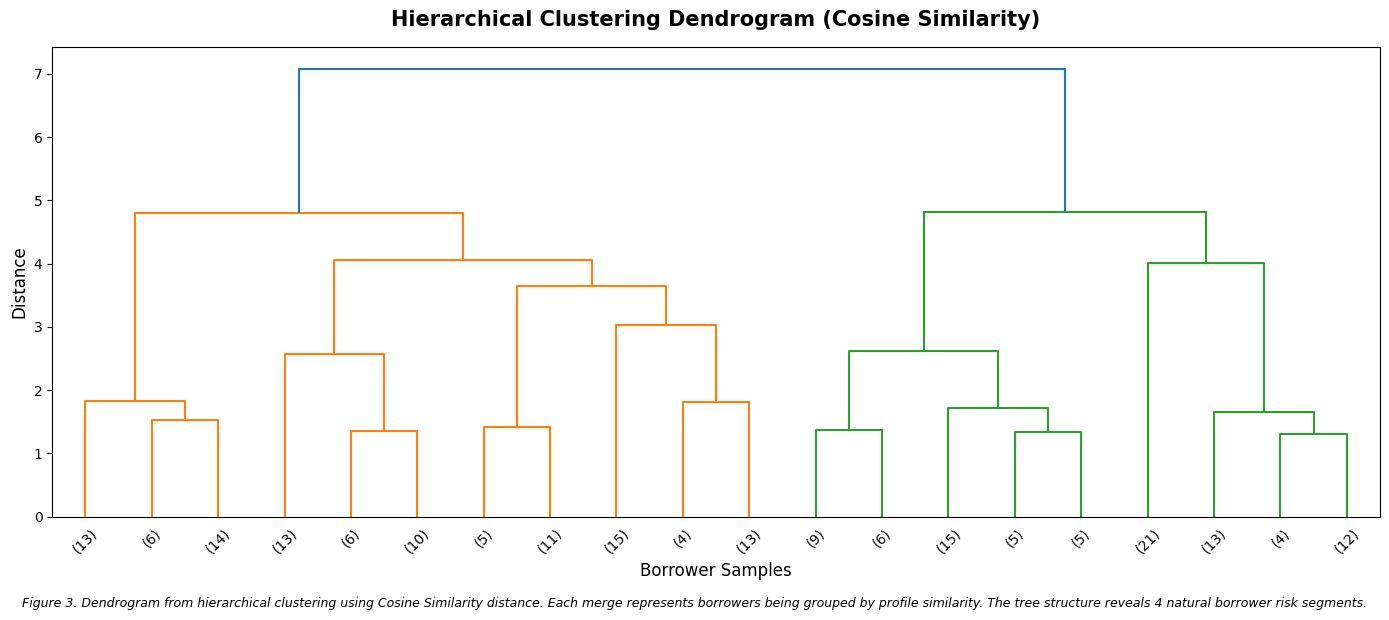

In [70]:
# Visualization 3 — Hierarchical Clustering Dendrogram
df_dendro = df_cluster.sample(200, random_state=42)[cluster_features]
X_dendro = scaler.transform(df_dendro)

distances = pdist(X_dendro, metric='cosine')
Z = linkage(distances, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=20,
           leaf_rotation=45, leaf_font_size=10,
           color_threshold=0.7*max(Z[:,2]))

plt.title('Hierarchical Clustering Dendrogram (Cosine Similarity)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Borrower Samples', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.figtext(0.5, -0.02,
            'Figure 3. Dendrogram from hierarchical clustering using Cosine Similarity distance. '
            'Each merge represents borrowers being grouped by profile similarity. '
            'The tree structure reveals 4 natural borrower risk segments.',
            ha='center', fontsize=9, style='italic', wrap=True)
plt.tight_layout()
plt.savefig('clustering_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

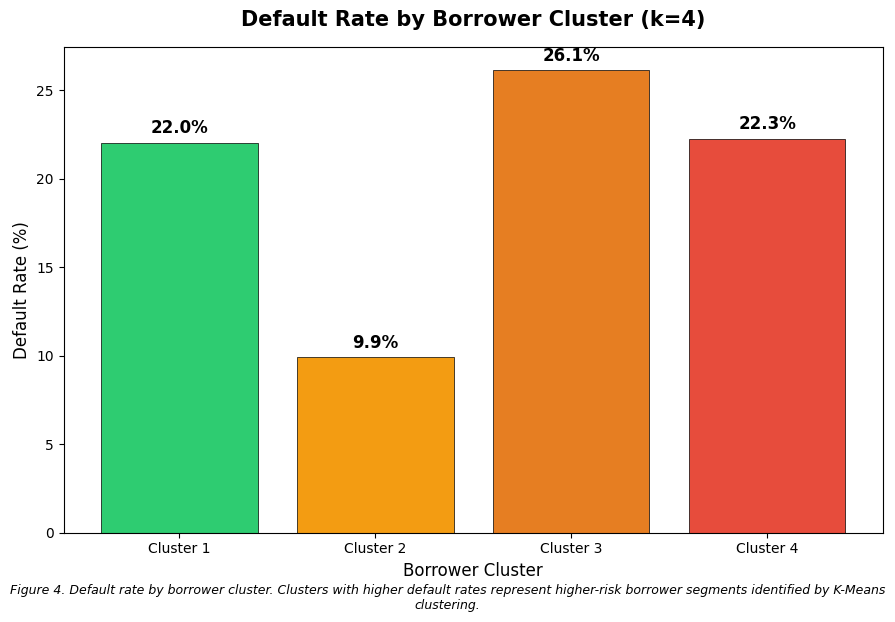

In [71]:
# Visualization 4 — Default Rate by Cluster
df_loans_sample_cluster = df_loans[cluster_features].dropna().sample(5000, random_state=42).copy()
df_loans_sample_cluster['cluster'] = labels
df_loans_sample_cluster['default'] = df_loans.loc[df_loans_sample_cluster.index, 'default']

default_by_cluster = df_loans_sample_cluster.groupby('cluster')['default'].mean() * 100

plt.figure(figsize=(9, 6))
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
bars = plt.bar([f'Cluster {i+1}' for i in range(4)],
               default_by_cluster.values,
               color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, default_by_cluster.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Default Rate by Borrower Cluster (k=4)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Borrower Cluster', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)
plt.figtext(0.5, -0.02,
            'Figure 4. Default rate by borrower cluster. Clusters with higher default rates represent '
            'higher-risk borrower segments identified by K-Means clustering.',
            ha='center', fontsize=9, style='italic', wrap=True)
plt.tight_layout()
plt.savefig('clustering_default_rate.png', dpi=150, bbox_inches='tight')
plt.show()

In [72]:
# Show clustering data sample - screenshot this
print("CLUSTERING DATA SAMPLE — First 5 rows (Unlabeled Numeric Features):")
print(df_cluster[cluster_features].head())

CLUSTERING DATA SAMPLE — First 5 rows (Unlabeled Numeric Features):
         loan_amnt  int_rate  annual_inc    dti  fico_range_low  revol_util  \
703466     15000.0     12.49    112000.0   6.74           675.0        70.0   
144872     11000.0     12.69     38000.0  33.92           670.0        33.9   
317962     30000.0     18.84    160000.0   2.42           705.0        30.1   
1018621     6075.0     14.30     21600.0  27.06           705.0        39.8   
545309     30000.0     17.99    192000.0  21.71           665.0        75.5   

         delinq_2yrs  total_acc  pub_rec  
703466           1.0       29.0      0.0  
144872           1.0       31.0      1.0  
317962           1.0       20.0      0.0  
1018621          0.0       14.0      0.0  
545309           0.0       21.0      0.0  


In [73]:
# PCA Analysis
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f} ({var*100:.1f}%)")
print(f"\nCumulative variance (first 2 PCs): {sum(pca.explained_variance_ratio_[:2])*100:.1f}%")

Explained variance ratio:
PC1: 0.2123 (21.2%)
PC2: 0.1843 (18.4%)
PC3: 0.1263 (12.6%)
PC4: 0.1246 (12.5%)
PC5: 0.1129 (11.3%)
PC6: 0.0878 (8.8%)
PC7: 0.0673 (6.7%)
PC8: 0.0470 (4.7%)
PC9: 0.0375 (3.7%)

Cumulative variance (first 2 PCs): 39.7%


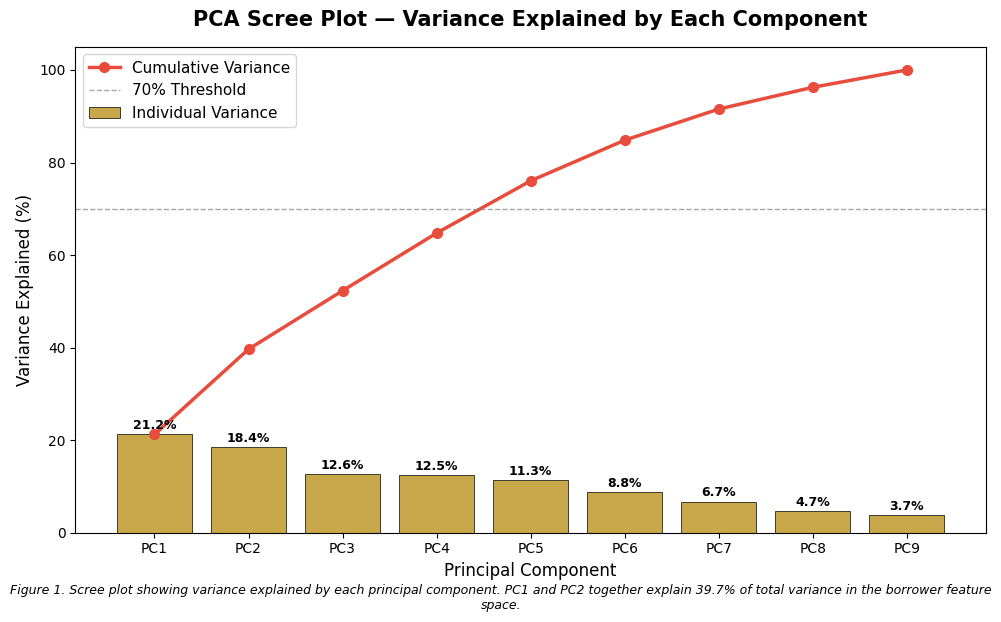

In [74]:
# PCA Visualization 1 — Scree Plot
plt.figure(figsize=(10, 6))

variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratio)
pc_labels = [f'PC{i+1}' for i in range(len(variance_ratio))]

plt.bar(pc_labels, variance_ratio * 100, color='#c8a84b',
        edgecolor='black', linewidth=0.5, label='Individual Variance')
plt.plot(pc_labels, cumulative_variance * 100,
         color='#e74c3c', marker='o', linewidth=2.5,
         markersize=7, label='Cumulative Variance')

for i, (var, cum) in enumerate(zip(variance_ratio, cumulative_variance)):
    plt.text(i, var * 100 + 0.5, f'{var*100:.1f}%',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.axhline(y=70, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='70% Threshold')
plt.title('PCA Scree Plot — Variance Explained by Each Component',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Variance Explained (%)', fontsize=12)
plt.legend(fontsize=11)
plt.figtext(0.5, -0.02,
            'Figure 1. Scree plot showing variance explained by each principal component. '
            'PC1 and PC2 together explain 39.7% of total variance in the borrower feature space.',
            ha='center', fontsize=9, style='italic', wrap=True)
plt.tight_layout()
plt.savefig('pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

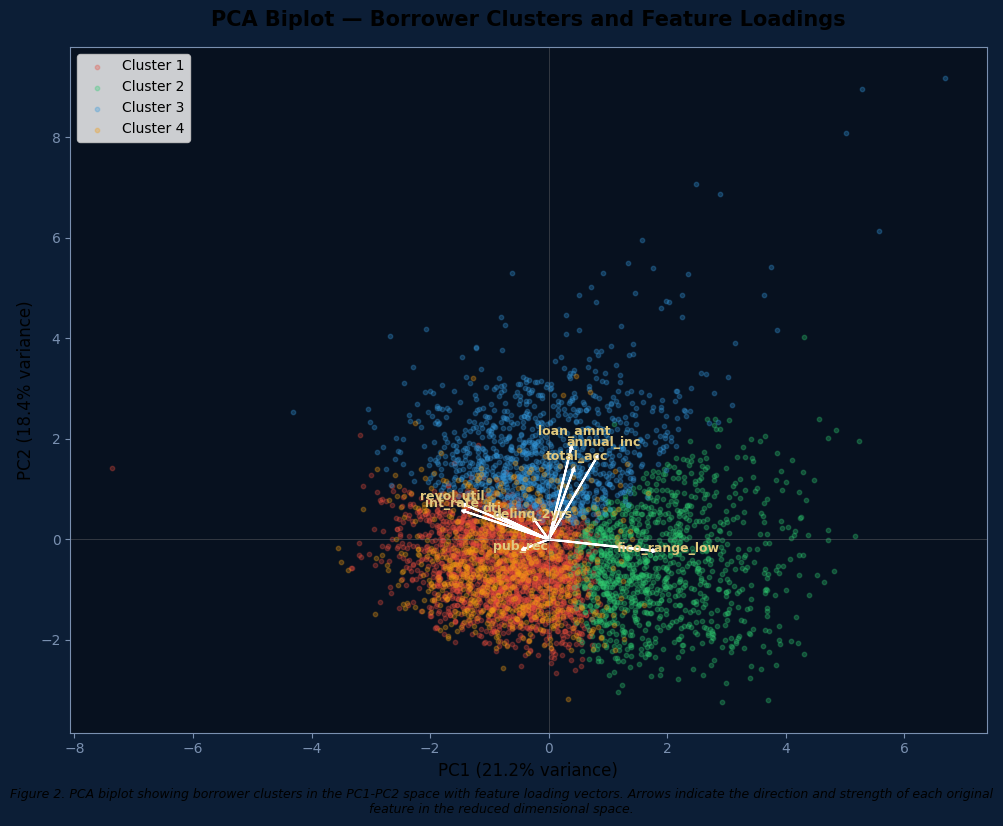

In [79]:
# PCA Visualization 2 — Biplot (PC1 vs PC2)
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
for i in range(4):
    mask = labels == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[i], alpha=0.3, s=10, label=f'Cluster {i+1}')

feature_names = cluster_features
loadings = pca.components_.T
scale = 3

for i, feature in enumerate(feature_names):
    ax.arrow(0, 0, loadings[i, 0]*scale, loadings[i, 1]*scale,
             head_width=0.05, head_length=0.05,
             fc='white', ec='white', linewidth=1.5)
    ax.text(loadings[i, 0]*scale*1.15, loadings[i, 1]*scale*1.15,
            feature, fontsize=9, color='#e2c97e', fontweight='bold', ha='center')

ax.set_xlabel(f'PC1 ({variance_ratio[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({variance_ratio[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA Biplot — Borrower Clusters and Feature Loadings',
             fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.axhline(y=0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5, alpha=0.5)
ax.set_facecolor('#07111f')
fig.patch.set_facecolor('#0c1e36')
ax.tick_params(colors='#7a90b0')
ax.spines['bottom'].set_color('#7a90b0')
ax.spines['left'].set_color('#7a90b0')
ax.spines['top'].set_color('#7a90b0')
ax.spines['right'].set_color('#7a90b0')

plt.figtext(0.5, -0.02,
            'Figure 2. PCA biplot showing borrower clusters in the PC1-PC2 space with feature loading vectors. '
            'Arrows indicate the direction and strength of each original feature in the reduced dimensional space.',
            ha='center', fontsize=9, style='italic', wrap=True)
plt.tight_layout()
plt.savefig('pca_biplot.png', dpi=150, bbox_inches='tight')
plt.show()